# JaiaBot with YSI comparisons (WITH CSV)

In [1]:
#Just your imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [19]:
# File paths (they will be different for you)
ysi_file = "YSI_data.csv"

jaia_files = [
    "TestTubeFirstSet.csv",
    "TestTubeSecondSet.csv",

]

experiment_start = pd.to_datetime("2026-04-29 13:20:00")

# JAIA column names
jaia_time_col = "Time"
jaia_temp_col = "Temperature"
jaia_temp_alt_col = "TSYS01Data/temperature"
jaia_depth_col = "PressureAdjustedData/depth"

### Load and clean YSI data

This section imports the YSI data file and prepares it for comparison with the JAIA Bot measurements. The raw YSI file contains an extra header row, so the first row is used as the column names and then removed from the dataset. A datetime column is created by combining the DATE and TIME columns, which allows the YSI data to be filtered and aligned by time. Temperature, salinity, and depth are converted into numeric values so they can be plotted and analyzed. Finally, the dataset is filtered to the experiment period after 1:20 PM and sorted chronologically. (

In [24]:
#loading YSI data

ysi = pd.read_csv(
    ysi_file,
    encoding="utf-16",
    skiprows=8
)

# Fix header
ysi.columns = ysi.iloc[0]
ysi = ysi.iloc[1:].copy()

# Create datetime 
ysi["time"] = pd.to_datetime(
    ysi["DATE (M/d/yyyy)"] + " " + ysi["TIME (h:mm:ss tt)"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)


# Convert important columns
ysi["temp"] = pd.to_numeric(ysi["TEMP °C"], errors="coerce")
ysi["sal"] = pd.to_numeric(ysi["SAL PSU"], errors="coerce")
ysi["depth"] = pd.to_numeric(ysi["DEPTH M"], errors="coerce")

# Keep only the YSI data collected during the experiment window 
ysi = ysi[ysi["time"] >= pd.to_datetime("2025-04-29 13:20:00")].copy()

# Sort
ysi = ysi.sort_values("time").reset_index(drop=True)


### Load and clean JAIA Bot data

This section imports the JAIA Bot mission data files and combines them into one dataset. The JAIA timestamps are originally recorded in UTC, so they are converted to local New York time to match the YSI data (both are in EST). A source column is added so each row can still be traced back to its original mission file. The main JAIA temperature sensor and the TSYS01 temperature sensor are converted into numeric columns for analysis. Finally, the JAIA data is filtered to the same experiment time window as the YSI data and sorted by time.

In [25]:
# load JaiaBot data

#creates an list to store each JaiaBot Missionfile
jaia_list = []

#loop through each Jaia file
for file in jaia_files:

    #Reads JaiaBot file
    df = pd.read_csv(file)

    # Convert JaiaBot time from UTC to local New York time
    # This can be changed as need be
    df["time"] = pd.to_datetime(df["Time"], utc=True)
    df["time"] = df["time"].dt.tz_convert("America/New_York").dt.tz_localize(None)

    df["source"] = file

    jaia_list.append(df)

# Combine all JAIA files tot he list
jaia = pd.concat(jaia_list, ignore_index=True)

# Convert JaiaBot temperature columns to numeric values
jaia["temp"] = pd.to_numeric(jaia["Temperature"], errors="coerce")
jaia["temp_alt"] = pd.to_numeric(jaia["TSYS01Data/temperature"], errors="coerce")
jaia["depth"] = pd.to_numeric(jaia[jaia_depth_col], errors="coerce")

# Filter JAIA data to the experiment window
jaia = jaia[jaia["time"] >= experiment_start].copy()

# Remove rows with missing values in key columns
jaia = jaia.dropna(subset=["time", "temp", "temp_alt", "depth"]).copy()

# Sort JaiaBot data by time 
jaia = jaia.sort_values("time").reset_index(drop=True)

In [26]:
# Time check to make sure both the JaiaBot and Ysi overlap

print("YSI time range:")
print(ysi["time"].min(), "to", ysi["time"].max())

print("\nJAIA time range:")
print(jaia["time"].min(), "to", jaia["time"].max())

print("\nJAIA by file:")
print(jaia.groupby("source")["time"].agg(["min", "max", "count"]))

YSI time range:
2026-04-29 13:30:04 to 2026-04-29 13:47:34

JAIA time range:
2026-04-29 13:27:18.715000 to 2026-04-29 13:48:09.178000

JAIA by file:
                                          min                     max  count
source                                                                      
TestTubeFirstSet.csv  2026-04-29 13:27:18.715 2026-04-29 13:37:29.715    612
TestTubeSecondSet.csv 2026-04-29 13:40:24.178 2026-04-29 13:48:09.178    466


### Raw temperature comparison with JAIA recorded depth

This diagnostic figure compares YSI temperature, JAIA main temperature, JAIA TSYS01 temperature, and JAIA recorded depth through time. The depth record now comes from the JAIA pressure-adjusted depth column rather than the YSI depth record. This allows the JAIA temperature response to be viewed directly alongside the vehicle’s own recorded vertical movement during the experiment.

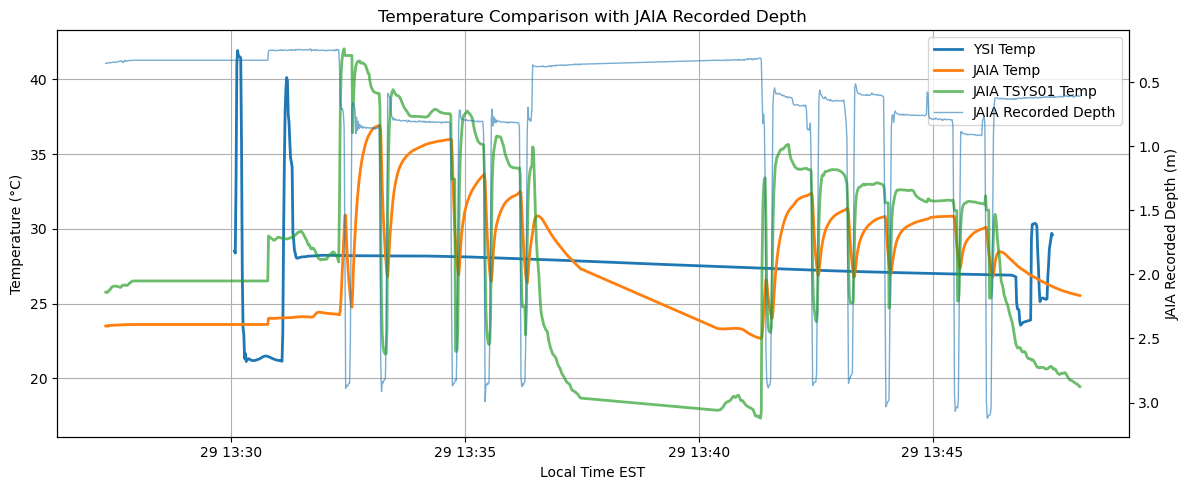

In [23]:

# Temperature comaprison with Jaiabot recorded depth

fig, ax1 = plt.subplots(figsize=(12, 5))

# Temperature lines

# YSI temperature
ax1.plot(
    ysi["time"],
    ysi["temp"],
    label="YSI Temp",
    linewidth=2
)

# JaiaBot main temperature sensor
ax1.plot(
    jaia["time"],
    jaia["temp"],
    label="JAIA Temp",
    linewidth=2
)

# JaiaBot TSYS01 temperature sensor
ax1.plot(
    jaia["time"],
    jaia["temp_alt"],
    label="JAIA TSYS01 Temp",
    linewidth=2,
    alpha=0.7
)

# Temperature axis labels
ax1.set_title("Temperature Comparison with JAIA Recorded Depth")
ax1.set_xlabel("Local Time EST")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(True)

# JAIA recorded depth on right axis
ax2 = ax1.twinx()

ax2.plot(
    jaia["time"],
    jaia["depth"],
    label="JAIA Recorded Depth",
    linewidth=1,
    alpha=0.6
)

ax2.set_ylabel("JAIA Recorded Depth (m)")
ax2.invert_yaxis()

# Combined legend

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis settings

This section defines the main settings used throughout the notebook, including the experiment time window, JAIA depth cutoff, and profile detection parameters. Keeping these values in one place makes the analysis easier to rerun and adjust. The TSYS01 temperature column is used for profile detection because it showed clearer temperature swings during the pipe/profile experiment.

In [7]:
# Jaiabot depth cutoff for removing shallow/surface records
# This keeps only the part of the dataset collected during the pipe/profile experiment.*change as needed)

start_time = pd.Timestamp("2026-04-29 13:27:00")
stop_time  = pd.Timestamp("2026-04-29 13:48:30")

# Jaiabot depth cutoff
# Values shallower than this may represent near-surface/top-pipe conditions.
surface_cutoff = 0.45   

# JAIA profile detection settings
# The TSYS01 temperature sensor is used because it shows stronger warm/cold swings.
cycle_col = "temp_alt"        

# Warm/top-pipe temperature threshold used to help separate profile cycles.
top_temp_threshold = 35     

# Minimum number of seconds required for a profile to be kept.
min_profile_seconds = 5

# Minimum number of data points required for a profile to be kept.
min_points = 8

### Prepare YSI data for comparison

This section creates a cleaned YSI dataset for the main experiment window. YSI temperature is kept for comparison with the JAIA temperature sensors. YSI depth is still retained as a reference quality-control variable, but the main JAIA profile analysis uses the JAIA pressure-adjusted depth column.

In [8]:
# PREPARE YSI DATA FOR COMPARISON

# Keep only rows with valid YSI time, temperature, and depth values
ysi_work = ysi.dropna(subset=["time", "temp", "depth"]).copy()

# Filter YSI data to the main experiment time window
ysi_work = ysi_work[
    (ysi_work["time"] >= start_time) &
    (ysi_work["time"] <= stop_time)
].copy()

# Sort YSI data by time
ysi_work = ysi_work.sort_values("time").reset_index(drop=True)

# Print quick quality-control information
print("YSI time range:")
print(ysi_work["time"].min(), "to", ysi_work["time"].max())

print("\nYSI temperature range:")
print(ysi_work["temp"].min(), "to", ysi_work["temp"].max())

print("\nYSI depth range for reference only:")
print(ysi_work["depth"].min(), "to", ysi_work["depth"].max())

YSI time range:
2026-04-29 13:30:04 to 2026-04-29 13:47:34

YSI temperature range:
21.123 to 41.933

YSI depth range for reference only:
0.327 to 2.942


### Prepare JAIA data for dive analysis
This section creates a cleaned JAIA dataset for the main experiment window. Rows with missing time, temperature, TSYS01 temperature, or recorded depth values are removed. The cleaned JAIA data is then filtered to the experiment period and sorted by time so it can be used for profile detection and temperature-depth analysis.

In [9]:
# Prepare Jaiabot Data

# Keep only rows with valid time, temperature, and recorded depth values
jaia_pipe = jaia.dropna(subset=["time", "temp", "temp_alt", "depth"]).copy()

# Filter Jaiabot data to the main experiment time window
jaia_pipe = jaia_pipe[
    (jaia_pipe["time"] >= start_time) &
    (jaia_pipe["time"] <= stop_time)
].copy()

# Sort Jaiabot data by time
jaia_pipe = jaia_pipe.sort_values("time").reset_index(drop=True)

# Print quick quality-control information
print("JAIA time range:")
print(jaia_pipe["time"].min(), "to", jaia_pipe["time"].max())

print("\nJAIA rows:", len(jaia_pipe))

print("\nJAIA recorded depth range:")
print(jaia_pipe["depth"].min(), "to", jaia_pipe["depth"].max())

JAIA time range:
2026-04-29 13:27:18.715000 to 2026-04-29 13:48:09.178000

JAIA rows: 1078

JAIA recorded depth range:
0.2408774891545648 to 3.122825529475836


### Detect individual jaiabot dives using recorded depth

This section detects individual JAIA profiles using the pressure-adjusted depth column from the JAIA dataset. A profile is identified when the JAIA depth is greater than the shallow/surface cutoff. Each detected profile is summarized by its start time, stop time, duration, number of points, maximum depth, and temperature range.

In [10]:
# detect individual Jaiabot dives using depth peaks
# Make a clean working copy of JAIA data
jaia_dive = jaia_pipe.dropna(subset=["time", "depth", "temp", "temp_alt"]).copy()

# Keep only the main experiment window
jaia_dive = jaia_dive[
    (jaia_dive["time"] >= start_time) &
    (jaia_dive["time"] <= stop_time)
].copy()

# Sort by time
jaia_dive = jaia_dive.sort_values("time").reset_index(drop=True)

# Settings for identifying individual dives
deep_threshold = 2.0       # minimum depth for a dive bottom
min_peak_spacing_s = 20    # minimum time between dive bottoms
window_seconds = 12        # seconds before and after each dive bottom

# Find candidate bottom points where depth is deeper than nearby values
candidate_rows = []

for i in range(1, len(jaia_dive) - 1):

    prev_depth = jaia_dive.loc[i - 1, "depth"]
    this_depth = jaia_dive.loc[i, "depth"]
    next_depth = jaia_dive.loc[i + 1, "depth"]

    # Local depth maximum deeper than the threshold
    if (
        this_depth >= deep_threshold and
        this_depth >= prev_depth and
        this_depth >= next_depth
    ):
        candidate_rows.append({
            "time": jaia_dive.loc[i, "time"],
            "depth": this_depth
        })

candidate_bottoms = pd.DataFrame(candidate_rows)

# Remove duplicate bottom points that occur too close together
dive_bottoms = []

for _, row in candidate_bottoms.iterrows():

    bottom_time = row["time"]

    if len(dive_bottoms) == 0:
        dive_bottoms.append(row)
    else:
        last_time = dive_bottoms[-1]["time"]
        time_gap = (bottom_time - last_time).total_seconds()

        if time_gap >= min_peak_spacing_s:
            dive_bottoms.append(row)
        else:
            # If two candidates are too close, keep the deeper one
            if row["depth"] > dive_bottoms[-1]["depth"]:
                dive_bottoms[-1] = row

# Build one dive window around each bottom point
jaia_dive_rows = []

for bottom in dive_bottoms:

    bottom_time = bottom["time"]

    start = bottom_time - pd.Timedelta(seconds=window_seconds)
    stop = bottom_time + pd.Timedelta(seconds=window_seconds)

    dive = jaia_dive[
        (jaia_dive["time"] >= start) &
        (jaia_dive["time"] <= stop)
    ].copy()

    duration_s = (stop - start).total_seconds()

    if duration_s >= min_profile_seconds and len(dive) >= min_points:
        jaia_dive_rows.append({
            "dive_id": len(jaia_dive_rows),
            "start": dive["time"].min(),
            "stop": dive["time"].max(),
            "bottom_time": bottom_time,
            "duration_s": duration_s,
            "n_points": len(dive),
            "max_depth": dive["depth"].max(),
            "min_depth": dive["depth"].min(),
            "temp_min": dive["temp"].min(),
            "temp_max": dive["temp"].max(),
            "temp_alt_min": dive["temp_alt"].min(),
            "temp_alt_max": dive["temp_alt"].max()
        })

jaia_dive_table = pd.DataFrame(jaia_dive_rows)

print("Detected JAIA dives:", len(jaia_dive_table))
jaia_dive_table

Detected JAIA dives: 11


,dive_id,start,stop,bottom_time,duration_s,n_points,max_depth,min_depth,temp_min,temp_max,temp_alt_min,temp_alt_max
0,0,2026-04-29 13:32:14.715,2026-04-29 13:32:38.715,2026-04-29 13:32:26.715,24.0,25,2.889825,0.245914,24.249780,30.909605,27.783804,42.050092
1,1,2026-04-29 13:33:00.715,2026-04-29 13:33:24.715,2026-04-29 13:33:12.715,24.0,25,2.913828,0.587867,26.817021,36.925658,21.616948,39.361660
2,2,2026-04-29 13:34:31.715,2026-04-29 13:34:55.715,2026-04-29 13:34:43.715,24.0,25,2.870324,0.717611,26.920053,36.008000,21.781649,37.746069
3,3,2026-04-29 13:35:13.715,2026-04-29 13:35:37.715,2026-04-29 13:35:25.715,24.0,25,2.993188,0.710359,26.468872,33.672794,22.256452,36.286828
4,4,2026-04-29 13:36:00.715,2026-04-29 13:36:24.715,2026-04-29 13:36:12.715,24.0,25,2.876310,0.697256,26.387258,32.510241,22.908442,34.122553
5,5,2026-04-29 13:41:17.178,2026-04-29 13:41:41.178,2026-04-29 13:41:29.178,24.0,25,2.887072,0.312962,22.663194,28.310802,17.323926,34.845680
6,6,2026-04-29 13:42:14.178,2026-04-29 13:42:38.178,2026-04-29 13:42:26.178,24.0,25,2.867030,0.562501,26.884118,32.371469,23.776115,34.055729
7,7,2026-04-29 13:43:00.178,2026-04-29 13:43:24.178,2026-04-29 13:43:12.178,24.0,25,2.850020,0.514543,26.756781,31.372038,25.062535,33.899744
8,8,2026-04-29 13:43:48.178,2026-04-29 13:44:12.178,2026-04-29 13:44:00.178,24.0,25,3.033195,0.596669,26.991098,30.829328,24.697688,33.078954
9,9,2026-04-29 13:45:17.178,2026-04-29 13:45:41.178,2026-04-29 13:45:29.178,24.0,25,3.068067,0.790639,27.342260,30.849784,25.164981,31.929787


### Split JAIA dives into downcast and upcast sections

This function separates each detected JAIA profile into downcast and upcast portions using the recorded JAIA depth column. The deepest recorded depth is treated as the approximate turn around point of the profile. This replaces the earlier reference depth method because the updated JAIA dataset includes pressure-adjusted depth measurements.

In [11]:
# Splist each dive into upcast and downcast
# uses jaibot recorded depth

def split_jaia_dive(dive_row):
    """
    Takes one JAIA dive from jaia_dive_table and splits it into
    downcast and upcast sections using JAIA recorded depth.

    The deepest JAIA depth point is used as the approximate turn-around point.
    """

    # Select data for this dive time window
    this_dive = jaia_dive[
        (jaia_dive["time"] >= dive_row["start"]) &
        (jaia_dive["time"] <= dive_row["stop"])
    ].copy()

    # Sort by time
    this_dive = this_dive.sort_values("time").reset_index(drop=True)

    # Skip very short dives
    if len(this_dive) < 4:
        return None, None

    # Use deepest recorded JAIA depth as the bottom / turn-around point
    bottom_idx = this_dive["depth"].idxmax()

    # Downcast = beginning of dive to deepest point
    jaia_down = this_dive.loc[:bottom_idx].copy()

    # Upcast = deepest point to end of dive
    jaia_up = this_dive.loc[bottom_idx:].copy()

    # If one side is too short, split by halfway point instead
    if len(jaia_down) < 2 or len(jaia_up) < 2:
        mid_idx = len(this_dive) // 2
        jaia_down = this_dive.iloc[:mid_idx].copy()
        jaia_up = this_dive.iloc[mid_idx:].copy()

    # Skip dives that still do not have enough points
    if len(jaia_down) < 2 or len(jaia_up) < 2:
        return None, None

    return jaia_down, jaia_up

### Detect individual JAIA dives using recorded depth peaks

This section identifies individual JAIA dives using local maximum depth points from the pressure-adjusted depth record. Instead of grouping all data below a shallow cutoff into one long profile, the code detects each deeper depth peak as a separate dive bottom. A short time window is then placed around each bottom point to capture the downcast and upcast portions of each dive.

**Note:** Dive 0 may not represent a complete dive cycle because it includes the initial transition from the surface/top-pipe condition into the water column. It is useful for quality control, but later dives provide more reliable downcast–upcast comparisons.

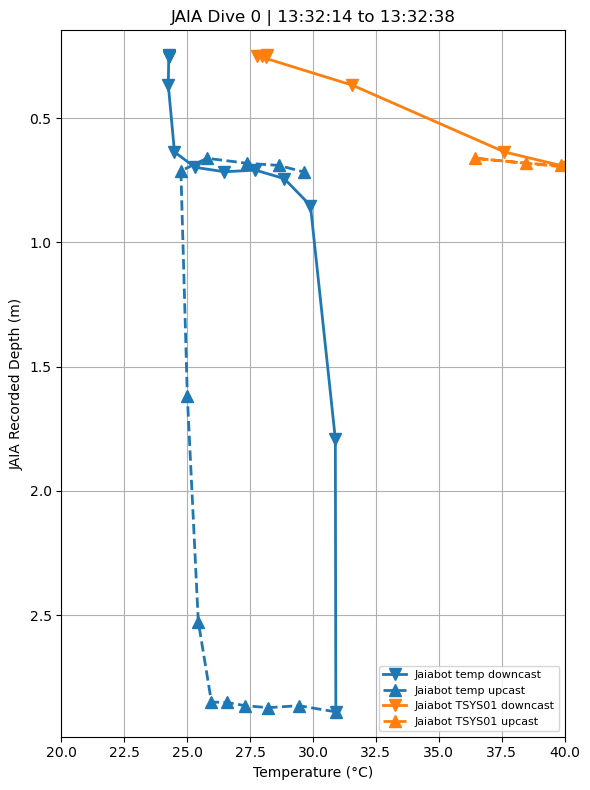

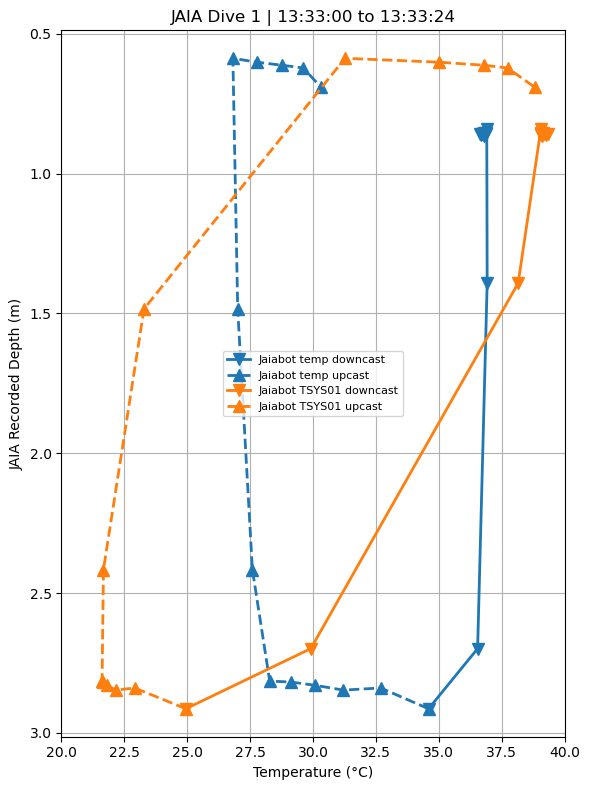

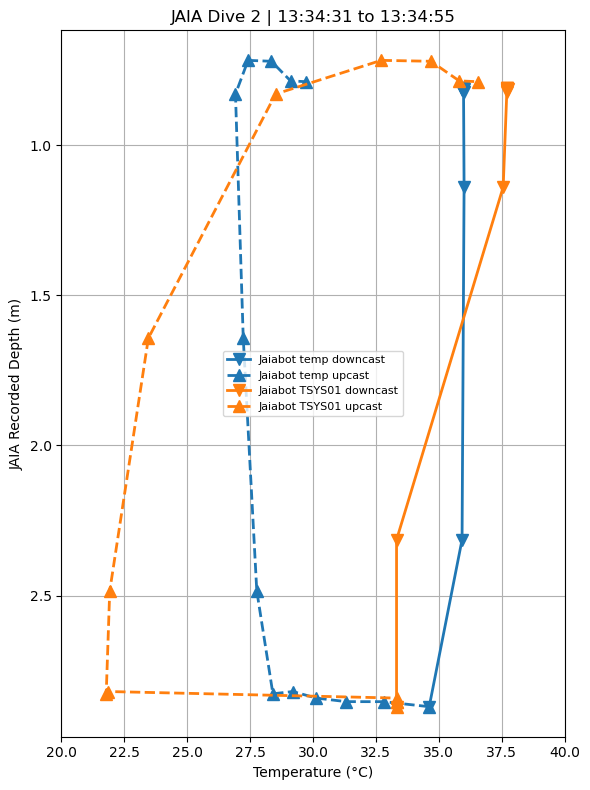

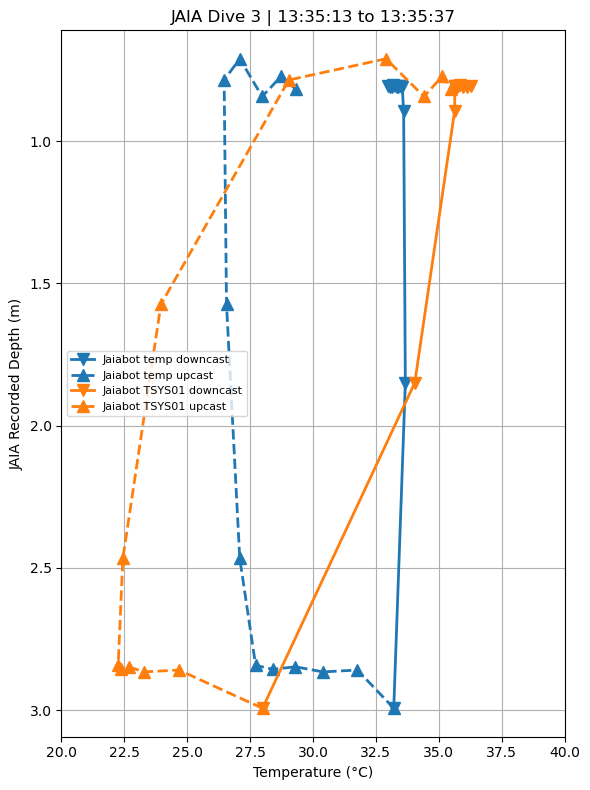

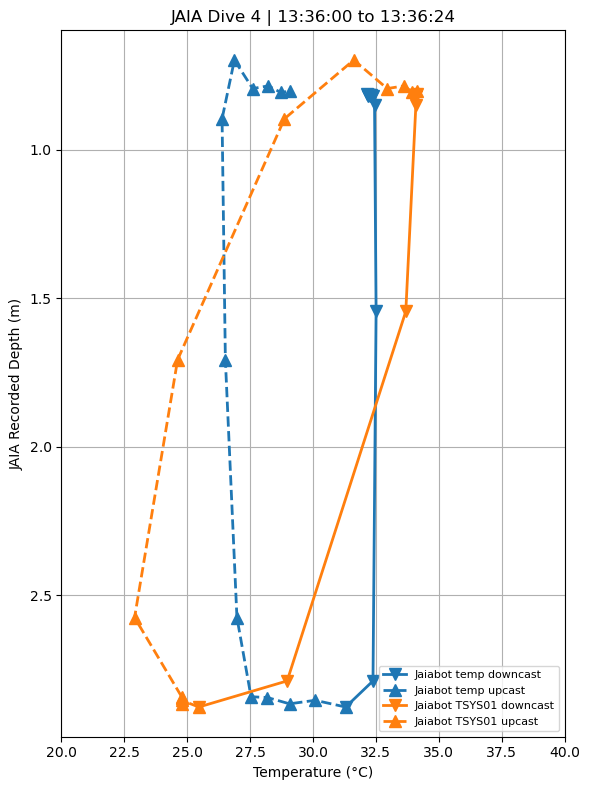

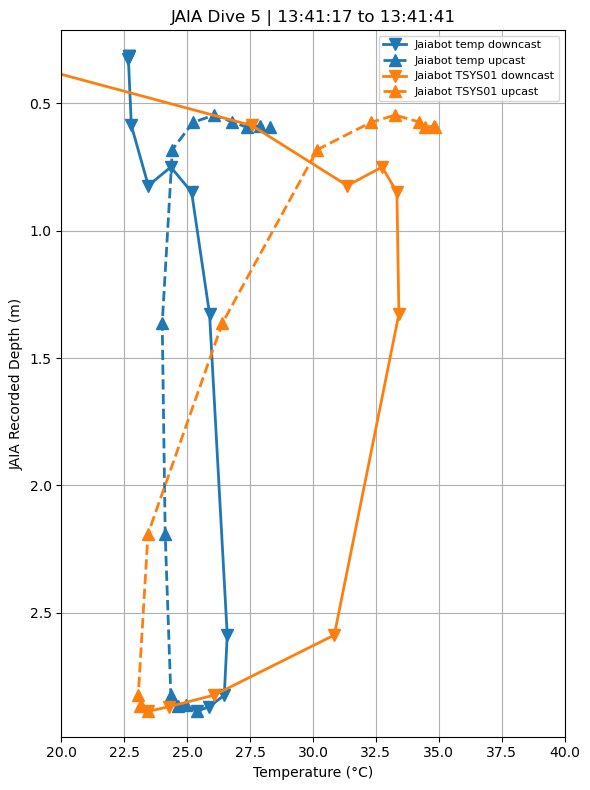

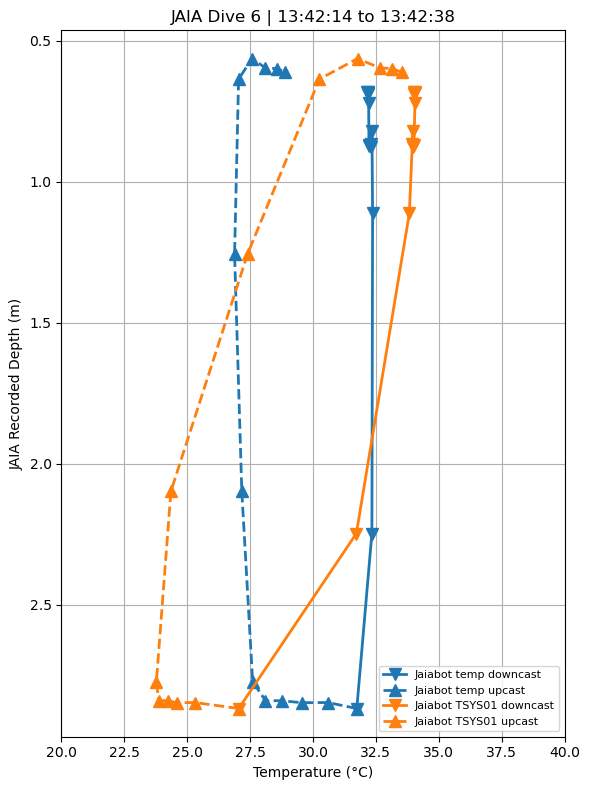

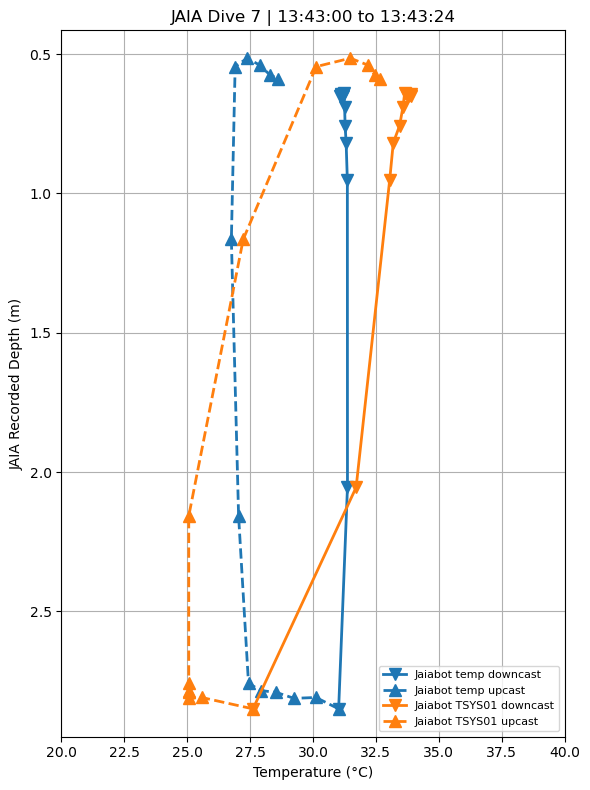

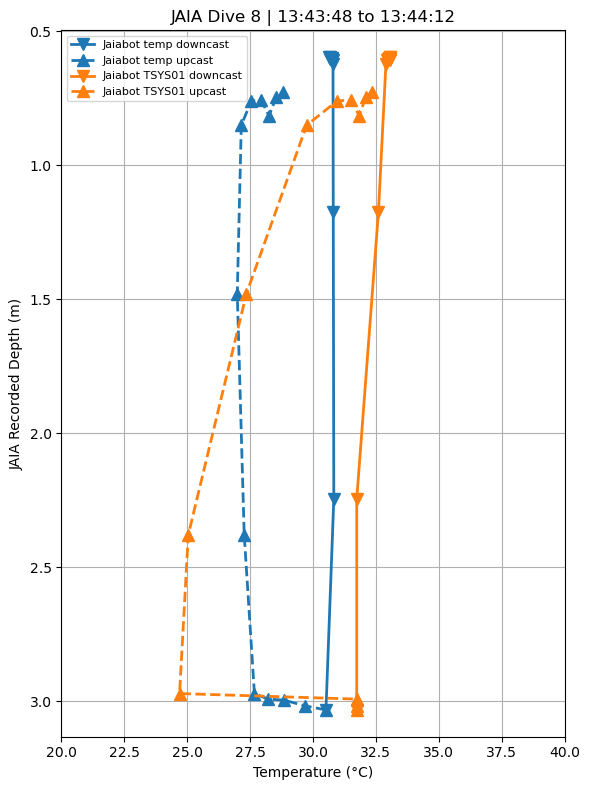

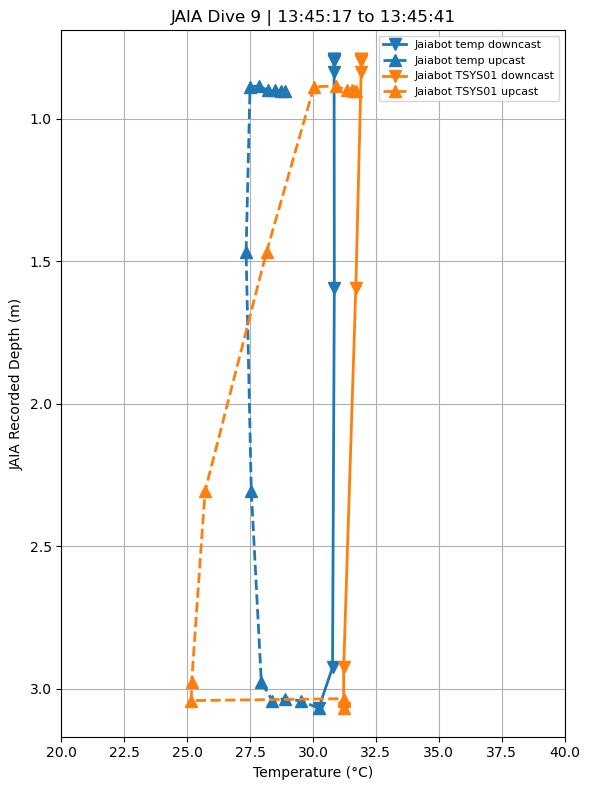

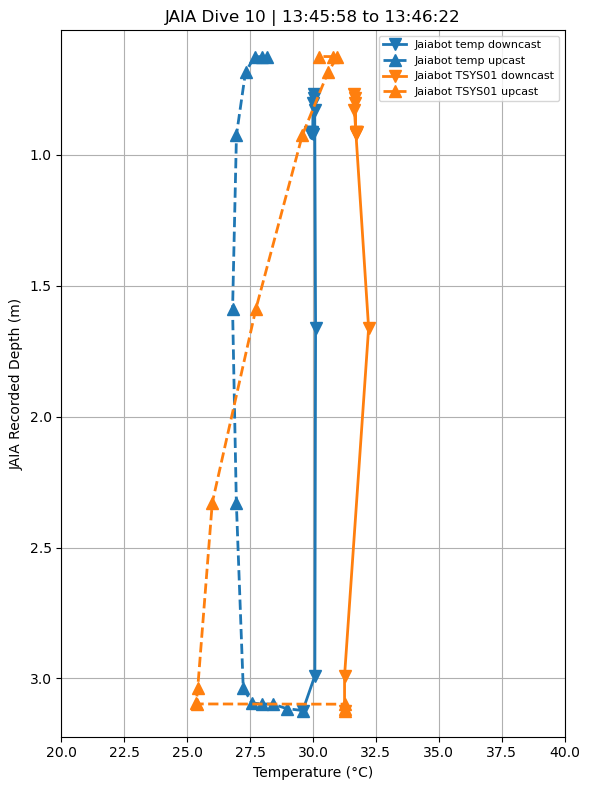

In [12]:
# plot each Jaiabot dives

# Set the same tighter temperature range for every plot
x_min = 20
x_max = 40

# Marker size for triangle markers
MARKER_SIZE = 8

for _, row in jaia_dive_table.iterrows():

    dive_id = int(row["dive_id"])

    # Split this dive into downcast and upcast sections
    downcast, upcast = split_jaia_dive(row)

    # Skip dives that do not have enough data
    if downcast is None or upcast is None:
        print(f"Skipped dive {dive_id}: not enough data")
        continue

    fig, ax = plt.subplots(figsize=(6, 8))

    # ------------------------------
    # JAIA main temperature sensor
    # Blue = JAIA main temp
    # Solid + down triangle = downcast
    # Dashed + up triangle = upcast
    # ------------------------------

    ax.plot(
        downcast["temp"],
        downcast["depth"],
        color="tab:blue",
        linestyle="-",
        marker="v",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot temp downcast"
    )

    ax.plot(
        upcast["temp"],
        upcast["depth"],
        color="tab:blue",
        linestyle="--",
        marker="^",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot temp upcast"
    )

    # Jaiabot TSYS01 temperature sensor
    # Orange = JAIA TSYS01 temp
    # Solid + down triangle = downcast
    # Dashed + up triangle = upcast

    ax.plot(
        downcast["temp_alt"],
        downcast["depth"],
        color="tab:orange",
        linestyle="-",
        marker="v",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot TSYS01 downcast"
    )

    ax.plot(
        upcast["temp_alt"],
        upcast["depth"],
        color="tab:orange",
        linestyle="--",
        marker="^",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot TSYS01 upcast"
    )

    # Use the same temperature x-axis range for every plot
    ax.set_xlim(x_min, x_max)

    # Set depth range based on this individual dive
    dive_depth_min = min(downcast["depth"].min(), upcast["depth"].min())
    dive_depth_max = max(downcast["depth"].max(), upcast["depth"].max())

    # Add a small buffer so the lines do not touch the plot edges
    depth_buffer = 0.10

    # Larger depth values are lower on the figure
    ax.set_ylim(dive_depth_max + depth_buffer, dive_depth_min - depth_buffer)

    ax.set_title(
        f"JAIA Dive {dive_id} | "
        f"{row['start'].strftime('%H:%M:%S')} to {row['stop'].strftime('%H:%M:%S')}"
    )

    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("JAIA Recorded Depth (m)")
    ax.grid(True)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Plot selected JAIA dives

This figure shows selected JAIA dives using the vehicle’s recorded depth. Each panel shows one dive, with the main JAIA temperature sensor and TSYS01 sensor plotted for both downcast and upcast portions. Sensor type is shown by color, while cast direction is shown by line style and triangle markers. Solid lines with downward triangles represent downcasts, and dashed lines with upward triangles represent upcasts.

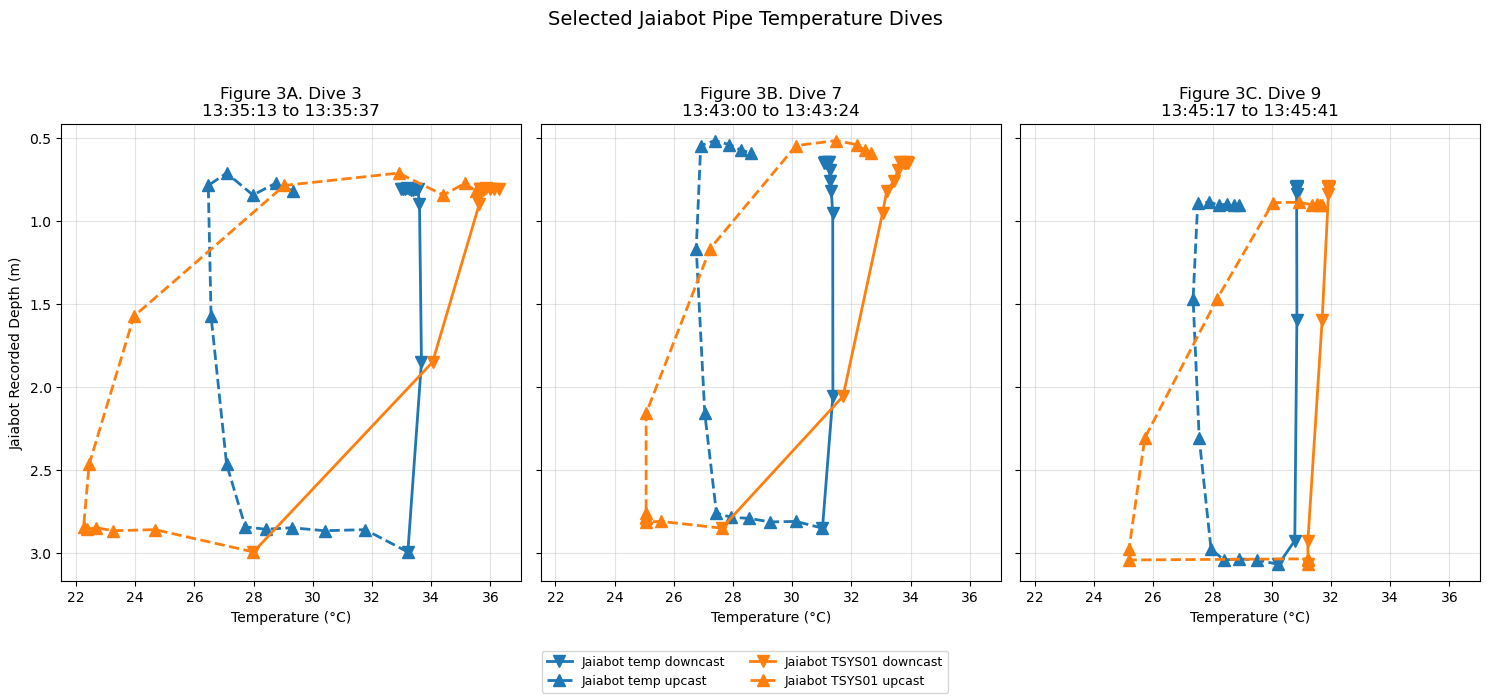

In [13]:
#Selected Jaiabot dives

selected_dives = [3, 7, 9]
panel_labels = ["3A", "3B", "3C"]

# Marker size for triangle markers
MARKER_SIZE = 8

# gather selected dive data and find shared x-axis range

dive_data = []
all_temps = []

for dive_id in selected_dives:

    row = jaia_dive_table[
        jaia_dive_table["dive_id"] == dive_id
    ].iloc[0]

    downcast, upcast = split_jaia_dive(row)

    if downcast is None or upcast is None:
        print(f"Skipped dive {dive_id}: not enough data")
        continue

    dive_data.append({
        "dive_id": dive_id,
        "row": row,
        "down": downcast,
        "up": upcast
    })

    # Collect temperatures for consistent x-axis
    all_temps.extend(downcast["temp"].dropna().tolist())
    all_temps.extend(upcast["temp"].dropna().tolist())
    all_temps.extend(downcast["temp_alt"].dropna().tolist())
    all_temps.extend(upcast["temp_alt"].dropna().tolist())

# Shared x-axis limits
temp_min = np.nanmin(all_temps)
temp_max = np.nanmax(all_temps)

# Add padding so lines do not touch plot edges
x_pad = 0.75
xlim = (temp_min - x_pad, temp_max + x_pad)

# Shared y-axis limits based on selected dives only
all_depths = []

for prof in dive_data:
    all_depths.extend(prof["down"]["depth"].dropna().tolist())
    all_depths.extend(prof["up"]["depth"].dropna().tolist())

depth_min = np.nanmin(all_depths)
depth_max = np.nanmax(all_depths)

depth_pad = 0.10
ylim = (depth_max + depth_pad, depth_min - depth_pad)

# PLOT

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 7),
    sharey=True
)

for ax, prof, panel_label in zip(axes, dive_data, panel_labels):

    dive_id = prof["dive_id"]
    row = prof["row"]
    downcast = prof["down"]
    upcast = prof["up"]

    # Put grid behind lines
    ax.set_axisbelow(True)

    # Jaiabot main temperature sensor
    # Blue = Jaiabot main temp
    # Solid + down triangle = downcast
    # Dashed + up triangle = upcast

    ax.plot(
        downcast["temp"],
        downcast["depth"],
        color="tab:blue",
        linestyle="-",
        marker="v",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot temp downcast",
        zorder=3
    )

    ax.plot(
        upcast["temp"],
        upcast["depth"],
        color="tab:blue",
        linestyle="--",
        marker="^",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot temp upcast",
        zorder=3
    )

    # Jaiabot TSYS01 temperature sensor
    # Orange = Jaiabot TSYS01 temp
    # Solid + down triangle = downcast
    # Dashed + up triangle = upcast

    ax.plot(
        downcast["temp_alt"],
        downcast["depth"],
        color="tab:orange",
        linestyle="-",
        marker="v",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot TSYS01 downcast",
        zorder=3
    )

    ax.plot(
        upcast["temp_alt"],
        upcast["depth"],
        color="tab:orange",
        linestyle="--",
        marker="^",
        linewidth=2,
        markersize=MARKER_SIZE,
        label="Jaiabot TSYS01 upcast",
        zorder=3
    )

    # Formatting

    # Same temperature x-axis for all three panels
    ax.set_xlim(xlim)

    # Same depth y-axis for all three panels
    # Larger depth values are lower on the figure
    ax.set_ylim(ylim)

    ax.grid(
        True,
        alpha=0.35,
        zorder=0
    )

    ax.set_title(
        f"Figure {panel_label}. Dive {dive_id}\n"
        f"{row['start'].strftime('%H:%M:%S')} to {row['stop'].strftime('%H:%M:%S')}"
    )

    ax.set_xlabel("Temperature (°C)")

# Only left panel needs y-label
axes[0].set_ylabel("Jaiabot Recorded Depth (m)")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    fontsize=9
)

plt.suptitle("Selected Jaiabot Pipe Temperature Dives", fontsize=14)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])
plt.show()

### Calculate upcast-downcast temperature bias

This section calculates the temperature difference between the upcast and downcast portions of each JAIA dive. Each dive is first split into downcast and upcast sections, then both sections are interpolated onto the same JAIA recorded-depth grid. Bias is calculated as upcast temperature minus downcast temperature at matching depths. This allows the two JAIA temperature sensors to be compared based on how much their upcast and downcast measurements differ during repeated pipe dives.

In [14]:
# calculate upcast-downcast temperature bias
bias_rows = []

# Number of depth points used for each dive comparison
n_depth_points = 30

for _, row in jaia_dive_table.iterrows():

    dive_id = int(row["dive_id"])

    # Split this dive into downcast and upcast
    downcast, upcast = split_jaia_dive(row)

    if downcast is None or upcast is None:
        print(f"Skipped dive {dive_id}: not enough data")
        continue

    # Keep only needed columns and remove missing values
    downcast = downcast[["depth", "temp", "temp_alt"]].dropna().copy()
    upcast = upcast[["depth", "temp", "temp_alt"]].dropna().copy()

    # Sort by depth for interpolation
    downcast = downcast.sort_values("depth")
    upcast = upcast.sort_values("depth")

    # Average duplicate depth values if they exist
    downcast = downcast.groupby("depth", as_index=False).mean()
    upcast = upcast.groupby("depth", as_index=False).mean()

    # Find overlapping depth range between downcast and upcast
    min_overlap_depth = max(downcast["depth"].min(), upcast["depth"].min())
    max_overlap_depth = min(downcast["depth"].max(), upcast["depth"].max())

    # Skip if overlap is too small
    if max_overlap_depth <= min_overlap_depth:
        print(f"Skipped dive {dive_id}: no overlapping depth range")
        continue

    # Create a common depth grid for this dive
    depth_grid = np.linspace(
        min_overlap_depth,
        max_overlap_depth,
        n_depth_points
    )

    # Interpolate Jaiabot main temperature to the common depth grid
    down_temp_interp = np.interp(
        depth_grid,
        downcast["depth"],
        downcast["temp"]
    )

    up_temp_interp = np.interp(
        depth_grid,
        upcast["depth"],
        upcast["temp"]
    )

    # Interpolate Jaiabot TSYS01 temperature to the common depth grid
    down_temp_alt_interp = np.interp(
        depth_grid,
        downcast["depth"],
        downcast["temp_alt"]
    )

    up_temp_alt_interp = np.interp(
        depth_grid,
        upcast["depth"],
        upcast["temp_alt"]
    )

    # Store the bias values
    for depth, down_t, up_t, down_alt, up_alt in zip(
        depth_grid,
        down_temp_interp,
        up_temp_interp,
        down_temp_alt_interp,
        up_temp_alt_interp
    ):

        bias_rows.append({
            "dive_id": dive_id,
            "depth": depth,
            "sensor": "Jaiabot temp",
            "downcast_temp": down_t,
            "upcast_temp": up_t,
            "bias": up_t - down_t
        })

        bias_rows.append({
            "dive_id": dive_id,
            "depth": depth,
            "sensor": "Jaiabot TSYS01",
            "downcast_temp": down_alt,
            "upcast_temp": up_alt,
            "bias": up_alt - down_alt
        })

# Convert results to dataframe
bias_df = pd.DataFrame(bias_rows)

print("Number of bias values:", len(bias_df))
bias_df.head()

Number of bias values: 660


,dive_id,depth,sensor,downcast_temp,upcast_temp,bias
0,0,0.660969,Jaiabot temp,24.830153,25.787358,0.957205
1,0,0.660969,Jaiabot TSYS01,38.654363,36.435314,-2.219049
2,0,0.737826,Jaiabot temp,28.427031,29.541470,1.114439
3,0,0.737826,Jaiabot TSYS01,41.776948,40.507247,-1.269701
4,0,0.814683,Jaiabot temp,29.547778,29.145917,-0.401861


### Remove Dive 0 from bias summary

Dive 0 is removed from the final bias summary because it likely includes the initial transition from the surface/top-pipe condition into the water rather than a complete downcast-upcast cycle. Removing this dive provides a cleaner comparison of repeated pipe dives that better represent complete dive cycles.

In [15]:
# Remove Dive 0 from the bias results
bias_df_no_dive0 = bias_df[bias_df["dive_id"] != 0].copy()

bias_summary_no_dive0 = (
    bias_df_no_dive0
    .groupby("sensor")["bias"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

bias_summary_no_dive0

,sensor,count,mean,median,std,min,max
0,Jaiabot TSYS01,300,-6.390456,-6.051860,3.239832,-14.286049,7.232341
1,Jaiabot temp,300,-4.759180,-4.405431,2.497410,-9.888586,3.316851


### Visualize upcast-downcast temperature bias

This boxplot shows the distribution of upcast-downcast temperature bias for the main JAIA temperature sensor and the TSYS01 sensor. The dashed horizontal line marks zero bias, where upcast and downcast temperatures would be equal. Negative values indicate that the upcast was cooler than the downcast at the same recorded depth, while positive values indicate that the upcast was warmer. Dive 0 is excluded because it likely includes the initial transition from the surface/top-pipe condition into the water rather than a complete dive cycle.

In [16]:
print("Rows in bias_df_no_dive0:", len(bias_df_no_dive0))
print(bias_df_no_dive0["sensor"].value_counts())

Rows in bias_df_no_dive0: 600
sensor
Jaiabot temp      300
Jaiabot TSYS01    300
Name: count, dtype: int64


Jaiabot temp bias values: 300
Jaiabot TSYS01 bias values: 300


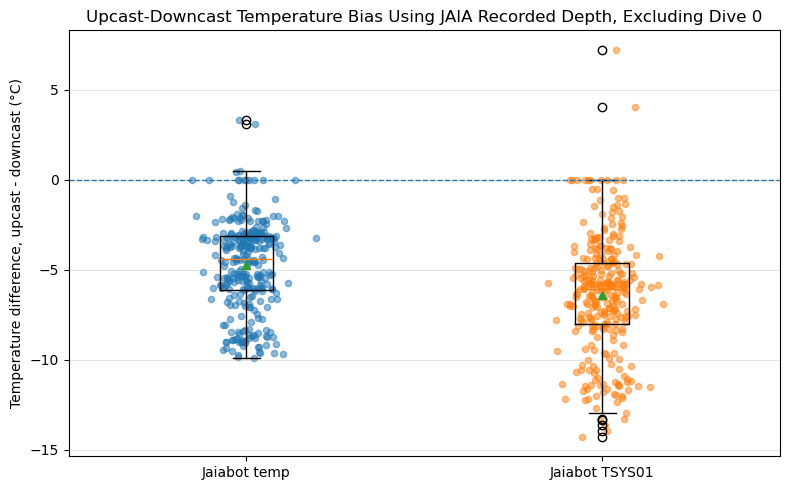

In [17]:
# boxplot of upcast-downcast temperature bias without dive 0


fig, ax = plt.subplots(figsize=(8, 5))

# Separate bias values by sensor
# These names must match exactly what appears in bias_df_no_dive0["sensor"]
jaia_temp_bias = bias_df_no_dive0.loc[
    bias_df_no_dive0["sensor"] == "Jaiabot temp",
    "bias"
].dropna()

tsys01_bias = bias_df_no_dive0.loc[
    bias_df_no_dive0["sensor"] == "Jaiabot TSYS01",
    "bias"
].dropna()

# Check that data was selected correctly
print("Jaiabot temp bias values:", len(jaia_temp_bias))
print("Jaiabot TSYS01 bias values:", len(tsys01_bias))

box_data = [jaia_temp_bias, tsys01_bias]
box_labels = ["Jaiabot temp", "Jaiabot TSYS01"]

# Create boxplot
ax.boxplot(
    box_data,
    tick_labels=box_labels,
    showmeans=True
)

# Add individual data points with slight horizontal jitter
for i, values in enumerate(box_data, start=1):
    x_jitter = np.random.normal(i, 0.05, size=len(values))

    ax.scatter(
        x_jitter,
        values,
        alpha=0.5,
        s=20
    )

# Add zero-bias reference line
ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Upcast-Downcast Temperature Bias Using JAIA Recorded Depth, Excluding Dive 0")
ax.set_ylabel("Temperature difference, upcast - downcast (°C)")
ax.grid(True, axis="y", alpha=0.35)

plt.tight_layout()
plt.show()